=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


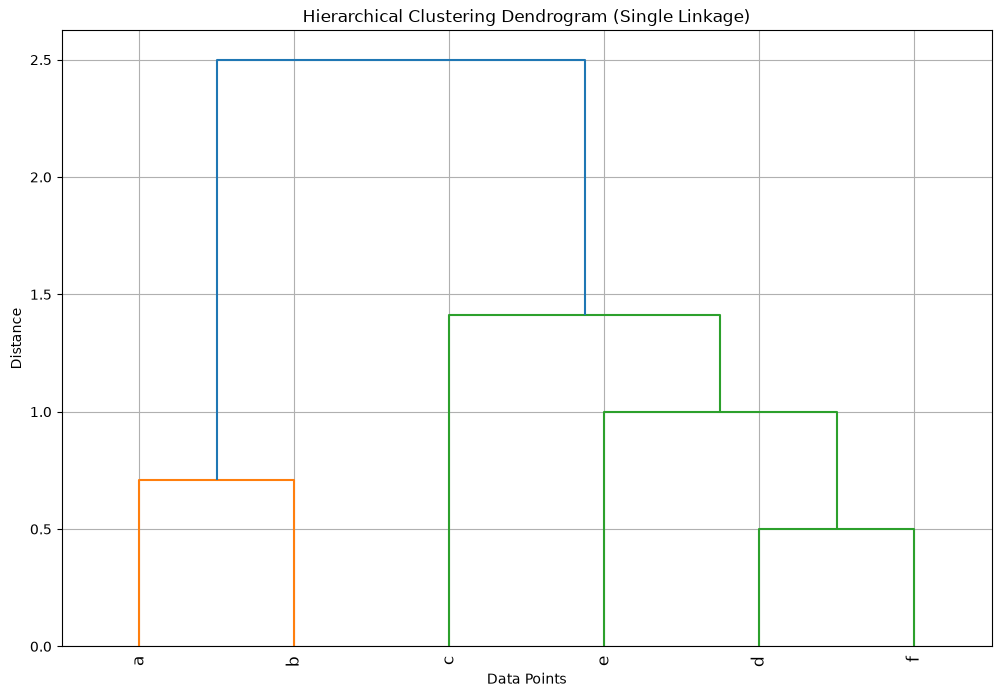

In [ ]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5] # f
])

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                            columns=['a', 'b', 'c', 'd', 'e', 'f'],
                            index=['a', 'b', 'c', 'd', 'e', 'f'])

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Penjelasan:
1. import numpy as np --> Mengimpor library NumPy yang digunakan untuk membuat dan mengolah data dalam bentuk array.
2. import pandas as pd --> Mengimpor Pandas untuk mengolah data dalam bentuk tabel atau DataFrame.Digunakan untuk menampilkan distance matrix.
3. linkage digunakan untuk melakukan proses Hierarchical Clustering.
4. dendrogram digunakan untuk menampilkan hasil clustering dalam bentuk diagram pohon.
5. pdist digunakan untuk menghitung jarak antar data.
6. squareform digunakan untuk mengubah hasil perhitungan jarak menjadi bentuk distance matrix.
7. import matplotlib.pyplot as plt --> Digunakan untuk membuat dan menampilkan grafik, termasuk dendrogram
8. Membuat dataset sederhana --> 
    1. Membuat dataset sederhana yang terdiri dari 6 data, yaitu a, b, c, d, e, dan f.
    2. Setiap data memiliki dua nilai/fitur yang menjadi koordinat.
    3. Dataset ini digunakan untuk memahami proses Hierarchical Clustering sebelum menggunakan dataset yang lebih besar.
9. Menghitung Euclidean Distance
    1. Menghitung jarak Euclidean antara setiap pasangan data.
    2. Jarak ini digunakan untuk mengetahui seberapa dekat atau jauh suatu data dengan data lainnya.
    3. Semakin kecil nilai jaraknya, semakin dekat posisi kedua data tersebut.
10. squareform() mengubah hasil pdist() menjadi matriks jarak.
11. Melakukan Hierarchical Clustering
    1. method='single' berarti menggunakan metode Single Linkage.
    2. Single Linkage menentukan jarak antarcluster berdasarkan jarak terdekat antara anggota dari kedua cluster.
    3. Hasil proses ini disimpan dalam variabel linked.
12. plt.figure(figsize=(12, 8)) menentukan ukuran grafik.
13. plt.title() memberikan judul pada dendrogram.
14. Judul menunjukkan bahwa clustering menggunakan Single Linkage.
15. Menampilkan Dendrogram
    1. dendrogram() digunakan untuk menampilkan hasil Hierarchical Clustering dalam bentuk diagram pohon.
    2. linked berisi hasil proses clustering sebelumnya.
    3. labels memberikan nama pada setiap data.
    4. leaf_rotation=90 memutar label data sebesar 90 derajat agar lebih mudah dibaca.
16. plt.grid(True) menampilkan garis bantu pada grafik.

In [9]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Penjelasan:
1. import pandas as pd mengimpor library Pandas.
2. pd.read_csv() digunakan untuk membaca dataset Mall_Customers.csv.
Data disimpan dalam variabel df.
3. df.head() menampilkan beberapa baris pertama dataset.

In [11]:
x = df.iloc[:, [3, 4]].values

Penjelasan:
1. Memilih kolom ke-4 dan ke-5 dari dataset.
2. Kolom tersebut adalah Annual Income (k$) dan Spending Score (1-100).
3. .values mengubah data yang dipilih menjadi array NumPy.
4. Kedua fitur tersebut digunakan untuk menentukan pengelompokan pelanggan.

In [12]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

Penjelasan:
1. StandardScaler digunakan untuk melakukan standardisasi data.
2. Tujuannya agar nilai dari fitur yang digunakan berada pada skala yang sebanding.
3. fit_transform(x) menghitung parameter standardisasi sekaligus menerapkannya pada data.
4. Hasil standardisasi disimpan dalam scaled_data.

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

Penjelasan:
1. Mengimpor fungsi linkage dan dendrogram.
2. linkage() digunakan untuk melakukan Hierarchical Clustering.
3. scaled_data merupakan data yang sudah distandardisasi.
4. method="complete" berarti menggunakan metode Complete Linkage.
5. metric="euclidean" berarti jarak antar data dihitung menggunakan Euclidean Distance.
6. Hasil clustering disimpan dalam variabel clustering.

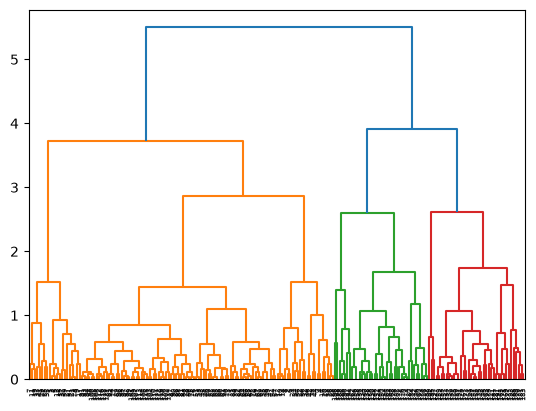

In [15]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

Penjelasan:
1. dendrogram(clustering) menampilkan hasil proses Hierarchical Clustering dalam bentuk dendrogram.
2. plt.show() menampilkan grafik tersebut.
3. Dendrogram digunakan untuk melihat bagaimana pelanggan dapat dikelompokkan berdasarkan kemiripan Annual Income dan Spending Score.

TUGAS PRAKTIKUM
NAMA: Anggi F. A. Br Sembiring
NIM: 42324057

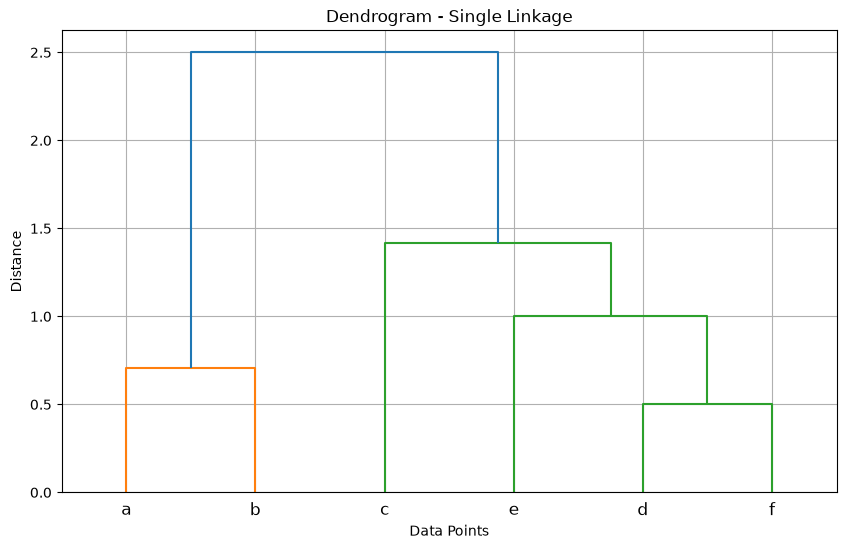

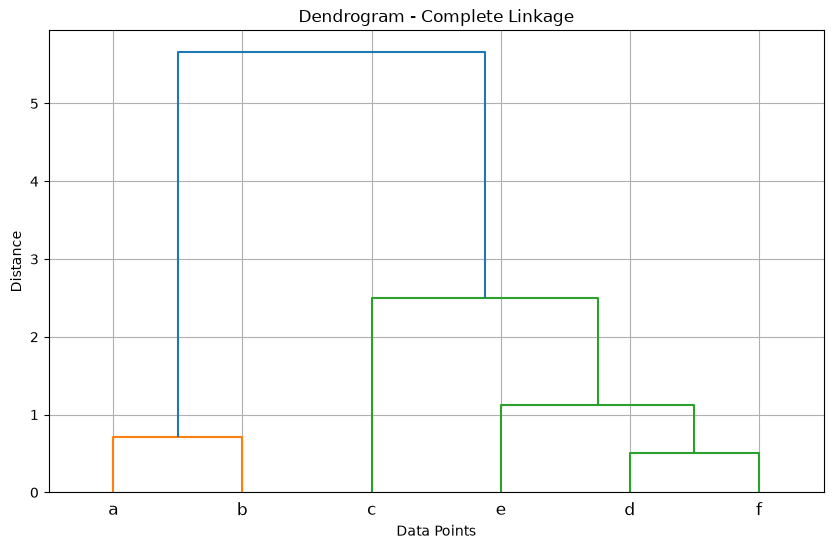

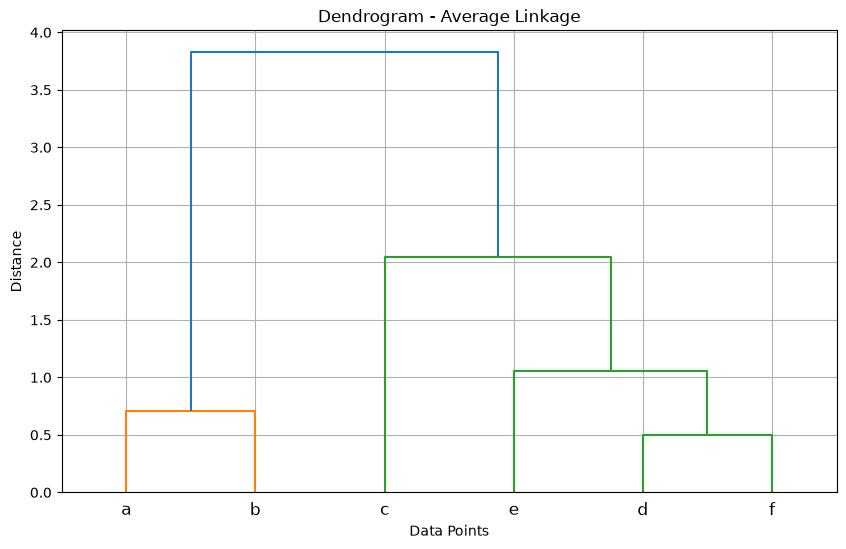

In [16]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

labels = ['a', 'b', 'c', 'd', 'e', 'f']

# Single Linkage
single = linkage(data, method='single', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(single, labels=labels)
plt.title("Dendrogram - Single Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

# Complete Linkage
complete = linkage(data, method='complete', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(complete, labels=labels)
plt.title("Dendrogram - Complete Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

# Average Linkage
average = linkage(data, method='average', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(average, labels=labels)
plt.title("Dendrogram - Average Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Penjelasan:
Berdasarkan percobaan Hierarchical Clustering pada dataset sederhana, dapat dilihat bahwa penggunaan metode Single Linkage, Complete Linkage, dan Average Linkage menghasilkan pola dendrogram yang berbeda. Perbedaan tersebut terjadi karena setiap metode memiliki cara yang berbeda dalam menentukan jarak antar-cluster. Single Linkage menggunakan jarak terdekat, Complete Linkage menggunakan jarak terjauh, sedangkan Average Linkage menggunakan rata-rata jarak antar data dalam cluster.

Dari hasil perbandingan ketiga dendrogram, dapat disimpulkan bahwa pemilihan metode linkage memengaruhi proses penggabungan data menjadi cluster. Oleh karena itu, metode linkage perlu dipilih sesuai dengan karakteristik data dan hasil clustering yang ingin diperoleh. Percobaan ini menunjukkan bahwa Hierarchical Clustering dapat digunakan untuk melihat hubungan dan kemiripan antar data secara bertahap melalui dendrogram.